### ε-δ 定义

对于函数 $f(x)$，如果对于任意 $\varepsilon > 0$，存在 $\delta > 0$，
使得当 $0 < |x - a| < \delta$ 时，有 $|f(x) - L| < \varepsilon$，
则称 $\lim_{x \to a} f(x) = L$。

In [1]:
import manim
from manim import *
from IPython.display import Video

# 设置 Manim 在 Jupyter 中的渲染参数
config.media_width = "70%"
config.verbosity = "WARNING"
config.quality = "medium_quality"   # 可改为 low_quality/high_quality

/home/apple/develop/learning/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apple/develop/learning/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20041 (\N{CJK UNIFIED IDEOGRAPH-4E49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apple/develop/learning/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apple/develop/learning/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/apple/develop/learning/venv/lib/python3.10/site-packages/IPython/core/pylabtoo

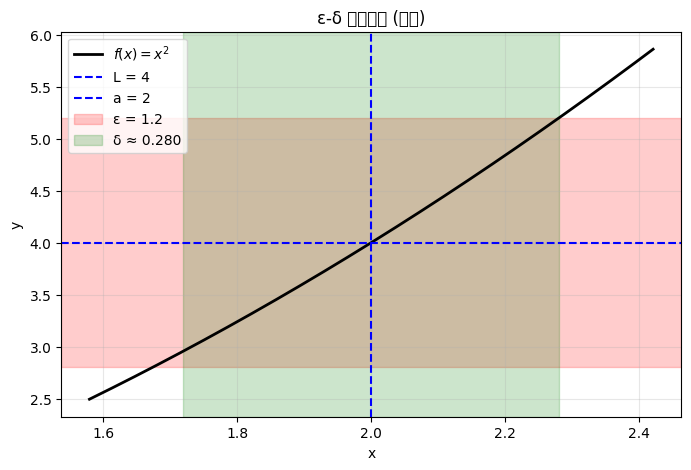

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 函数 f(x) = x^2，在 x=2 附近
a = 2
L = a**2
eps = 1.2
delta = np.sqrt(L + eps) - a  # 一个粗略的 δ，使 |f(x)-L| < eps

x = np.linspace(a - 1.5*delta, a + 1.5*delta, 400)
y = x**2

plt.figure(figsize=(8,5))
plt.plot(x, y, 'k', linewidth=2, label=r'$f(x)=x^2$')
plt.axhline(L, color='blue', linestyle='--', label=f'L = {L}')
plt.axvline(a, color='blue', linestyle='--', label=f'a = {a}')

# ε 带 (纵轴)
plt.axhspan(L - eps, L + eps, color='red', alpha=0.2, label=f'ε = {eps}')
# δ 带 (横轴) 对应 |x-a| < δ
plt.axvspan(a - delta, a + delta, color='green', alpha=0.2, label=f'δ ≈ {delta:.3f}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('ε-δ 定义示意 (静态)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
%%manim -v WARNING -qm EpsilonDelta

import numpy as np

class EpsilonDelta(MovingCameraScene):
    def construct(self):
        a = 2.0
        L = a ** 2
        x_min, x_max = 0.5, 3.5
        y_min, y_max = 0, 10

        # 坐标轴
        axes = Axes(
            x_range=[x_min, x_max, 0.5],
            y_range=[y_min, y_max, 2],
            axis_config={"include_numbers": True, "font_size": 24},
            tips=False,
        )
        x_label = axes.get_x_axis_label("x", edge=RIGHT, direction=RIGHT, buff=0.3)
        y_label = axes.get_y_axis_label("y", edge=UP, direction=UP, buff=0.3)
        self.add(axes, x_label, y_label)

        # 函数图像
        graph = axes.plot(lambda x: x**2, x_range=[x_min, x_max], color=WHITE, stroke_width=3)
        graph_label = MathTex("f(x)=x^2", font_size=36).next_to(graph, UP, buff=0.3).shift(RIGHT)
        self.play(Create(graph), Write(graph_label))
        self.wait(0.5)

        # 极限点
        dot_limit = Dot(axes.c2p(a, L), color=YELLOW, radius=0.12)
        lim_formula = MathTex(r"\lim_{x\to ", str(int(a)), r"} f(x) = ", str(int(L)), font_size=40)
        lim_formula.to_corner(UR).shift(LEFT * 0.5 + DOWN * 0.5)
        lim_formula[1].set_color(YELLOW)
        lim_formula[3].set_color(YELLOW)
        self.play(FadeIn(dot_limit), Write(lim_formula))
        self.wait(0.3)

        # ε-δ 控制器
        epsilon_tracker = ValueTracker(1.5)

        def get_delta(eps):
            if eps <= 0:
                return 0.01
            upper = np.sqrt(L + eps) - a
            lower = a - np.sqrt(max(L - eps, 0))
            return max(0.02, min(upper, lower, 1.0))

        # 水平 ε-带（直接用 Line，避免 get_horizontal_line 的参数问题）
        eps_initial = epsilon_tracker.get_value()
        epsilon_band = Line(
            axes.c2p(x_min, L + eps_initial),
            axes.c2p(x_max, L + eps_initial),
            color=RED, stroke_width=6, stroke_opacity=0.4
        )
        epsilon_band_low = Line(
            axes.c2p(x_min, L - eps_initial),
            axes.c2p(x_max, L - eps_initial),
            color=RED, stroke_width=6, stroke_opacity=0.4
        )
        eps_text = MathTex(r"\varepsilon = ", font_size=36)
        eps_value = DecimalNumber(eps_initial, num_decimal_places=2, font_size=36)
        eps_label = VGroup(eps_text, eps_value).arrange(RIGHT).next_to(lim_formula, DOWN, aligned_edge=LEFT)

        # 垂直 δ-带
        delta_initial = get_delta(eps_initial)
        delta_band_right = Line(
            axes.c2p(a + delta_initial, 0),
            axes.c2p(a + delta_initial, y_max),
            color=GREEN, stroke_width=6, stroke_opacity=0.4
        )
        delta_band_left = Line(
            axes.c2p(a - delta_initial, 0),
            axes.c2p(a - delta_initial, y_max),
            color=GREEN, stroke_width=6, stroke_opacity=0.4
        )
        delta_text = MathTex(r"\delta = ", font_size=36)
        delta_value = DecimalNumber(delta_initial, num_decimal_places=3, font_size=36)
        delta_label = VGroup(delta_text, delta_value).arrange(RIGHT).next_to(eps_label, DOWN, aligned_edge=LEFT)

        # 初始绘制
        self.add(epsilon_band, epsilon_band_low, delta_band_left, delta_band_right)
        self.play(Write(eps_label), Write(delta_label))
        self.wait(0.5)

        # 两次缩小 ε 演示
        self.play(epsilon_tracker.animate.set_value(0.5), run_time=3, rate_func=smooth)
        self.play(epsilon_tracker.animate.set_value(0.2), run_time=3, rate_func=smooth)
        self.wait(1)

        # 更新器：实时重绘水平线与垂直线
        def update_epsilon_band(band):
            new_y = L + epsilon_tracker.get_value()
            band.become(Line(
                axes.c2p(x_min, new_y), axes.c2p(x_max, new_y),
                color=RED, stroke_width=6, stroke_opacity=0.4
            ))
        def update_epsilon_band_low(band):
            new_y = L - epsilon_tracker.get_value()
            band.become(Line(
                axes.c2p(x_min, new_y), axes.c2p(x_max, new_y),
                color=RED, stroke_width=6, stroke_opacity=0.4
            ))
        def update_delta_right(line):
            d = get_delta(epsilon_tracker.get_value())
            line.become(Line(
                axes.c2p(a + d, 0), axes.c2p(a + d, y_max),
                color=GREEN, stroke_width=6, stroke_opacity=0.4
            ))
        def update_delta_left(line):
            d = get_delta(epsilon_tracker.get_value())
            line.become(Line(
                axes.c2p(a - d, 0), axes.c2p(a - d, y_max),
                color=GREEN, stroke_width=6, stroke_opacity=0.4
            ))

        epsilon_band.add_updater(update_epsilon_band)
        epsilon_band_low.add_updater(update_epsilon_band_low)
        delta_band_right.add_updater(update_delta_right)
        delta_band_left.add_updater(update_delta_left)

        eps_value.add_updater(lambda m: m.set_value(epsilon_tracker.get_value()))
        delta_value.add_updater(lambda m: m.set_value(get_delta(epsilon_tracker.get_value())))

        # 进一步动态演示
        self.play(epsilon_tracker.animate.set_value(1.2), run_time=2)
        self.play(epsilon_tracker.animate.set_value(0.05), run_time=4)
        self.wait(2)

Manim Community v0.19.1